In [1]:
import torch
from torch import nn
from torch.nn import functional as f
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from torchmetrics.classification import Accuracy, Recall


In [4]:
import random
import os
import numpy as np
import torch

def set_seed(seed=42):
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)        

set_seed(616) 
print("ok")

ok


In [5]:
df = pd.read_csv("/kaggle/input/datasets/fatemehmehrparvar/liver-disorders/Indian Liver Patient Dataset (ILPD).csv")
df.head(10)

df['A/G Ratio'] = df['A/G Ratio'].fillna(df['A/G Ratio'].mean())

labelencoder = LabelEncoder()
onehotencoder = OneHotEncoder()

df["Gender"] = labelencoder.fit_transform(df["Gender"])

onehot_df = onehotencoder.fit_transform(df[["Gender"]])
onehot_df = pd.DataFrame(onehot_df.toarray(), columns=["gender_male", "gender_female"])
df = pd.concat([df, onehot_df], axis=1)
df = df.drop(columns='Gender')

normal_liver = df[df["Selector"] == 2]
normal_liver = normal_liver.drop(columns = "Selector")

real_1 = df[df["Selector"] == 1]
real_1 = real_1.drop(columns = "Selector")

y = df["Selector"]
x = df.drop(columns = "Selector")


s_scaler = StandardScaler()
x = s_scaler.fit_transform(x)
normal_liver = s_scaler.fit_transform(normal_liver)
real_1 = s_scaler.fit_transform(real_1)

m_scaler = MinMaxScaler()
x = m_scaler.fit_transform(x)
normal_liver = m_scaler.fit_transform(normal_liver)
real_1 = m_scaler.fit_transform(real_1)

print("ok")

ok


In [6]:
x = x.astype(np.float32)
normal_liver = normal_liver.astype(np.float32)
real_1 = real_1 = real_1.astype(np.float32)

y = y.to_numpy()
y = y.astype(np.float32)

x = torch.from_numpy(x)
y = torch.from_numpy(y)
normal_liver = torch.from_numpy(normal_liver)
real_1 = torch.from_numpy(real_1)

y = (y == 1).float()
y.sum().item()
print("ok")

ok


In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=423)

In [8]:
class VAE(nn.Module):

    def __init__(self, input_dim=11, hidden_dim=32, latent_dim=8):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = f.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = f.relu(self.fc2(z))
        return f.sigmoid(self.fc3(h)) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

def vae_loss(recon_x, x, mu, logvar, kl_weight=0.01):
    recon_loss = f.binary_cross_entropy(recon_x, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + (kl_weight * kl_loss)
    return total_loss, recon_loss, kl_loss

vae_dataset = TensorDataset(normal_liver)
vae_loader = DataLoader(vae_dataset, batch_size=64, shuffle=True)

VAE_model = VAE()
optimizer = Adam(VAE_model.parameters(), lr=0.001)

epochs = 400

for epoch in range(epochs):
    VAE_model.train()
    total_VAEloss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    kl_weight = min(1.0, epoch / 50.0) * 0.1 

    for batch in vae_loader:
        x = batch[0]
        
        optimizer.zero_grad()
        recon, mu, logvar = VAE_model(x)
        VAEloss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, kl_weight)

        VAEloss.backward()
        optimizer.step()
        
        total_VAEloss += VAEloss.item() * len(x)
        total_recon_loss += recon_loss.item() * len(x)
        total_kl_loss += kl_loss.item() * len(x)

    total_samples = len(normal_liver)
    avg_loss = total_VAEloss / total_samples
    avg_recon_loss = total_recon_loss / total_samples
    avg_kl_loss = total_kl_loss / total_samples

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon_loss:.4f} | "
            f"KL: {avg_kl_loss:.4f} (wt: {kl_weight:.3f})"
        )


Epoch [1/400] Loss: 0.6897 | Recon: 0.6897 | KL: 0.0179 (wt: 0.000)
Epoch [10/400] Loss: 0.6305 | Recon: 0.6297 | KL: 0.0454 (wt: 0.018)
Epoch [20/400] Loss: 0.5656 | Recon: 0.5578 | KL: 0.2060 (wt: 0.038)
Epoch [30/400] Loss: 0.5369 | Recon: 0.5197 | KL: 0.2966 (wt: 0.058)
Epoch [40/400] Loss: 0.5241 | Recon: 0.5091 | KL: 0.1924 (wt: 0.078)
Epoch [50/400] Loss: 0.5087 | Recon: 0.4921 | KL: 0.1689 (wt: 0.098)
Epoch [60/400] Loss: 0.4883 | Recon: 0.4643 | KL: 0.2394 (wt: 0.100)
Epoch [70/400] Loss: 0.4666 | Recon: 0.4343 | KL: 0.3222 (wt: 0.100)
Epoch [80/400] Loss: 0.4477 | Recon: 0.4137 | KL: 0.3407 (wt: 0.100)
Epoch [90/400] Loss: 0.4399 | Recon: 0.4077 | KL: 0.3217 (wt: 0.100)
Epoch [100/400] Loss: 0.4400 | Recon: 0.4106 | KL: 0.2936 (wt: 0.100)
Epoch [110/400] Loss: 0.4337 | Recon: 0.4050 | KL: 0.2864 (wt: 0.100)
Epoch [120/400] Loss: 0.4303 | Recon: 0.4031 | KL: 0.2716 (wt: 0.100)
Epoch [130/400] Loss: 0.4310 | Recon: 0.4038 | KL: 0.2716 (wt: 0.100)
Epoch [140/400] Loss: 0.4308 | 

In [10]:
def sampling_fn(batch_size = 80):

    batch_size = batch_size
    latent_dim = 8 

    tensor = torch.randn(batch_size, latent_dim)
    y_tensor = torch.zeros(batch_size)

    new_data = VAE_model.decode(tensor).detach()

    x_train_sampling = torch.cat((x_train, new_data), dim=0)
    y_train_sampling = torch.cat((y_train, y_tensor), dim=0)

    perm_with_sampling = torch.randperm(x_train_sampling.size(0))
    x_train_sampling = x_train_sampling[perm_with_sampling]
    y_train_sampling = y_train_sampling[perm_with_sampling]

    return x_train_sampling, y_train_sampling

print("ok")

ok


In [11]:
def recon_error_fn(x, y):

    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x - x_hat)
        x_augmented = torch.cat((x, recon_error), dim=1) 

    perm = torch.randperm(x_augmented.size(0))
    x_train_recon = x_augmented[perm]
    y_train_recon = y[perm]

    return x_train_recon, y_train_recon
print("ok")


ok


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


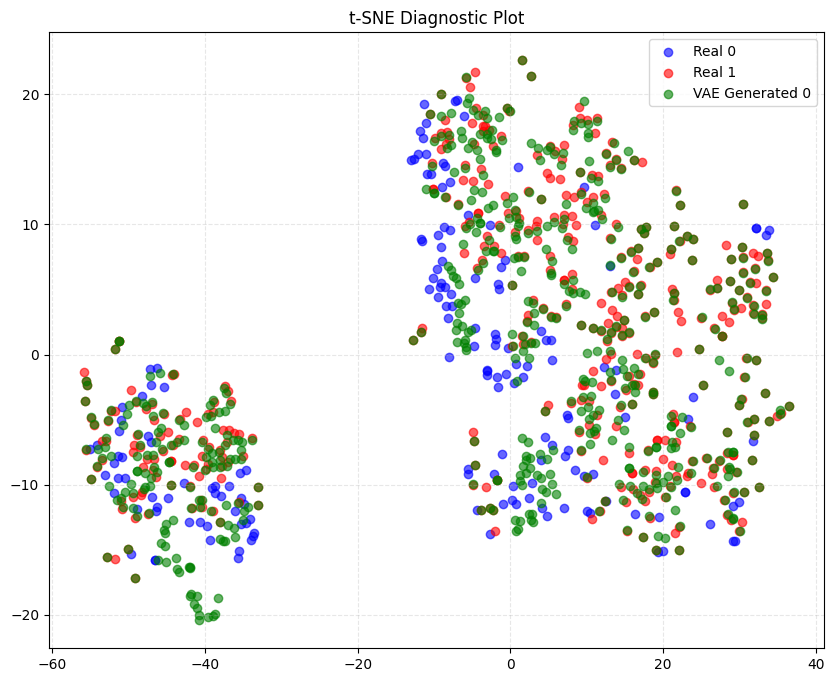

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

X_real_0 = normal_liver
X_real_1 = real_1
X_vae_0, _ = sampling_fn(80)
X = np.concatenate([X_real_0, X_real_1, X_vae_0], axis=0)

y = np.concatenate(
    [
        np.zeros(len(X_real_0)),
        np.ones(len(X_real_1)),
        np.ones(len(X_vae_0)) * 2,  
    ]
)


tsne = TSNE(n_components=2, perplexity=55, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
colors = ["blue", "red", "green"]
labels = ["Real 0", "Real 1", "VAE Generated 0"]

for i in range(3):
    idx = y == i
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        c=colors[i],
        label=labels[i],
        alpha=0.6,
    )
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend()
plt.title("t-SNE Diagnostic Plot")
plt.savefig("tsne_diagnostic_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [61]:
class ResBlock(nn.Module):
    def __init__(self, features = 512, bottleneck_features = 64):
        super().__init__()

        self.bn1 = nn.BatchNorm1d(features)
        self.fn1 = nn.Linear(features, bottleneck_features)
        
        self.bn2 = nn.BatchNorm1d(bottleneck_features)
        self.fn2 = nn.Linear(bottleneck_features, bottleneck_features)

        self.bn3 = nn.BatchNorm1d(bottleneck_features)
        self.fn3 = nn.Linear(bottleneck_features, features)
        
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        out = f.relu(self.bn1(x))
        out = self.dropout(self.fn1(out))
        
        out = f.relu(self.bn2(out))
        out = self.fn2(out)
        
        out = f.relu(self.bn3(out))
        out = self.fn3(out)
        
        return x + out

class BranchBlock(nn.Module):
    def __init__(self, features = 512, depth = 3):
        super().__init__()
        self.res_layers = nn.ModuleList([
            ResBlock(features = features) for _ in range(depth)
        ])

    def forward(self, x):
        for layer in self.res_layers:
            x = layer(x)
        return x

class Detection_model(nn.Module):
    def __init__(self, dim = 22, num_resBlocks = 5, num_branchs = 5, gate = False):
        super().__init__()
        self.input = nn.Linear(dim, 512)
        self.bn_in = nn.BatchNorm1d(512)
        
        self.fn1 = nn.Linear(512, 512)
        self.bn512_1 = nn.BatchNorm1d(512)

        self.parallel_branchs = nn.ModuleList([
            BranchBlock(features = 512, depth = num_resBlocks) for _ in range(num_branchs)
        ])
        
                
        self.fnc2 = nn.Linear(512, 512)
        self.bn512_2 = nn.BatchNorm1d(512)
        self.output = nn.Linear(512, 1)

        self.gate = gate
        if self.gate:
            self.weights = ElementWeight(features=512)
        else:
            self.register_parameter('weights', None)

    def forward(self, x):
        x = f.relu(self.bn_in(self.input(x)))
        x = f.relu(self.bn512_1(self.fn1(x)))

        parallel = sum(blocks(x) for blocks in self.parallel_branchs)
        
        if self.gate:
            parallel = self.weights(parallel)
        
        x = x + parallel 

        x = f.relu(self.bn512_2(self.fnc2(x)))
        x = self.output(x)

        return x

    def prediction(self, x):
        return self.forward(x)

class NN(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.input = nn.Linear(dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fn = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.output = nn.Linear(512, 1)

    def forward(self, x):
        x = f.relu(self.bn1(self.input(x)))
        x = f.relu(self.bn2(self.fn(x)))
        x = self.output(x)

        return x

class ElementWeight(nn.Module):
    def __init__(self, features=512):
        super().__init__()
        self.fn1 = nn.Linear(features, features)

    def forward(self, x):
        weights = torch.sigmoid(self.fn1(x))
        return x * weights

print("ok")

ok


In [79]:
mode = 9

if mode == 0:
    training_data = x_train
    target = y_train
    detection_model = NN(dim = 11)
    
elif mode == 1:
    training_data, target = sampling_fn()
    detection_model = NN(dim = 11)
    
elif mode == 2:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = NN(dim = 22)
    
elif mode == 3:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = NN(dim = 22)
    
elif mode == 4:
    training_data = x_train
    target = y_train
    detection_model = Detection_model(dim = 11)
    
elif mode == 5:
    training_data, target = sampling_fn()
    detection_model = Detection_model(dim = 11)
    
elif mode == 6:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 22)
    
elif mode == 7:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 22, gate = True)

elif mode == 8:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 22, gate = True)

else:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 22, gate = False)

train_dataset = TensorDataset(training_data, target)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#detection_model = Detection_model(num_resBlocks = 20, num_branchs = 5)
optim = AdamW(detection_model.parameters(), lr = 0.0001)

scheduler = ReduceLROnPlateau(optim, mode='min', factor=0.3, patience=10)

accuracy = Accuracy(task = "binary")
recall = Recall(task="binary")

epochs = 400

pos_weight = torch.tensor([0.8])

for epoch in range(epochs):
    detection_model.train()
    total_loss = 0
    
    epoch_preds = []
    epoch_targets = []

    for batch_x, batch_y in train_loader:
        optim.zero_grad()
        
        y_pred_logits = detection_model(batch_x)
        
        y_pred_logits = y_pred_logits.squeeze() 
        batch_y = batch_y.squeeze()

        loss = f.binary_cross_entropy_with_logits(y_pred_logits, batch_y, pos_weight = pos_weight)
        loss.backward()
        optim.step()

        total_loss += loss.item() * len(batch_y)
        
        y_pred_prob = torch.sigmoid(y_pred_logits)
        epoch_preds.append(y_pred_prob.detach())
        epoch_targets.append(batch_y.detach())
        
    avg_loss = total_loss / len(training_data)

    torch.nn.utils.clip_grad_norm_(detection_model.parameters(), max_norm=1.0)
    scheduler.step(avg_loss)
    
    all_preds = torch.cat(epoch_preds)
    all_targets = torch.cat(epoch_targets)
    
    acc_score = accuracy(all_preds, all_targets)
    recall_score = recall(all_preds, all_targets)
    
    if (epoch+1) % 10 == 0:
        
        current_lr = optim.param_groups[0]['lr']
        print(f"epoch:[{epoch+1}/{epochs}]  loss: {avg_loss:.4f}  acc: {acc_score:.4f}  recall:{recall_score:.4f}  lr:{current_lr:.10f}") 


epoch:[10/400]  loss: 0.3218  acc: 0.8260  recall:0.8389  lr:0.0001000000
epoch:[20/400]  loss: 0.2620  acc: 0.8901  recall:0.9027  lr:0.0001000000
epoch:[30/400]  loss: 0.1823  acc: 0.9158  recall:0.9362  lr:0.0001000000
epoch:[40/400]  loss: 0.1839  acc: 0.9176  recall:0.9271  lr:0.0001000000
epoch:[50/400]  loss: 0.1324  acc: 0.9432  recall:0.9605  lr:0.0001000000
epoch:[60/400]  loss: 0.1318  acc: 0.9322  recall:0.9544  lr:0.0001000000
epoch:[70/400]  loss: 0.1103  acc: 0.9524  recall:0.9483  lr:0.0001000000
epoch:[80/400]  loss: 0.1374  acc: 0.9359  recall:0.9483  lr:0.0001000000
epoch:[90/400]  loss: 0.0784  acc: 0.9689  recall:0.9666  lr:0.0000300000
epoch:[100/400]  loss: 0.0852  acc: 0.9689  recall:0.9757  lr:0.0000300000
epoch:[110/400]  loss: 0.0812  acc: 0.9652  recall:0.9666  lr:0.0000300000
epoch:[120/400]  loss: 0.0693  acc: 0.9744  recall:0.9757  lr:0.0000090000
epoch:[130/400]  loss: 0.0608  acc: 0.9744  recall:0.9726  lr:0.0000090000
epoch:[140/400]  loss: 0.0649  acc

In [80]:
if mode not in {0,1,4,5} :
    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x_test)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x_test - x_hat)
        x_augmented = torch.cat((x_test, recon_error), dim=1) 
    
    dataset = TensorDataset(x_augmented, y_test)

else:
    dataset = TensorDataset(x_test, y_test)
loader = DataLoader(dataset, batch_size=16, shuffle=False) 

all_preds = []
all_targets = []

detection_model.eval()

with torch.no_grad():
    for batch_x, batch_y in loader:
        
        y_logits = detection_model(batch_x)
        prob = torch.sigmoid(y_logits)
        
        y_pred = (prob >= 0.5).int()
        
        all_preds.append(y_pred.view(-1))
        all_targets.append(batch_y.view(-1))

final_preds = torch.cat(all_preds, dim=0)
final_targets = torch.cat(all_targets, dim=0).int()

accuracy.reset()
recall.reset()
metric_acc = accuracy(final_preds, final_targets)
metric_recall = recall(final_preds, final_targets)

print(f"--- 全測試集評估結果 ---")
print(f"Accuracy: {acc_score.item():.4f}")
print(f"Recall:   {recall_score.item():.4f}")

print("\n預測的前 50 筆結果:")
print(final_preds[:50].cpu().numpy()) 

--- 全測試集評估結果 ---
Accuracy: 0.9780
Recall:   0.9848

預測的前 50 筆結果:
[0 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 1 0 0 1 1 1 0 1
 1 0 1 1 1 1 1 0 1 1 1 0 1]
